 # Deep Learning - Assignment 2
 ## Siamese Networks for One-Shot Facial Recognition

 **Student Names:** Yuriy Rusanov, Elad Orpaz

 **ID(s):** 340915149, XXXXXXXXX

## 1. Setup and Imports

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models # For potentially using pre-trained features later
from PIL import Image
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm # For progress bars

In [17]:
# For reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.5.1
CUDA Available: True


## 2. Configuration

In [18]:
# --- Dataset Configuration ---
DATA_DIR = 'data/lfw2' # Root directory of the LFW dataset images
TRAIN_PAIRS_FILE = 'data/pairsDevTrain.txt'
TEST_PAIRS_FILE = 'data/pairsDevTest.txt'

# --- Image Preprocessing ---
IMG_SIZE = (105, 105) # Target image size as mentioned in the Koch et al. paper

# --- Training Configuration ---
NUM_EPOCHS = 10 # Adjust as needed
BATCH_SIZE = 64 # Adjust based on GPU memory
LEARNING_RATE = 0.00001 # Initial learning rate, adjust based on experiments
WEIGHT_DECAY = 0.0001 # L2 regularization

# --- Siamese Network Configuration ---
EMBEDDING_DIM = 4096 # Example dimension, adjust based on architecture

# --- Device Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 3. Dataset Parsing and Loading

 ### 3.1. Parse Pairs Files
 We need a function to read the `pairsDevTrain.txt` and `pairsDevTest.txt` files. These files have two formats:
 1.  **Positive Pairs:** `person_name\timg_num1\timg_num2` (Images of the same person)
 2.  **Negative Pairs:** `person_name1\timg_num1\tperson_name2\timg_num2` (Images of different people)

 We'll create pairs of image paths and a label (1 for same person, 0 for different).

In [19]:
def parse_pairs_file(file_path, data_dir):
    """
    Parses the LFW pairs file and returns a list of image pairs and labels.

    Args:
        file_path (str): Path to the pairs file (e.g., pairsDevTrain.txt).
        data_dir (str): Path to the directory containing LFW images.

    Returns:
        list: A list of tuples, where each tuple is ((img1_path, img2_path), label).
              label is 1 for a match (same person) and 0 for a mismatch.
    """
    pairs = []
    with open(file_path, 'r') as f:
        lines = f.readlines()
        num_pairs_info = int(lines[0].strip()) # First line contains the number of pairs of each type

        # Process lines for positive pairs (same person)
        for i in range(1, num_pairs_info + 1):
            line = lines[i].strip().split('\t')
            person_name = line[0]
            img_num1 = int(line[1])
            img_num2 = int(line[2])

            img1_path = os.path.join(data_dir, person_name, f"{person_name}_{img_num1:04d}.jpg")
            img2_path = os.path.join(data_dir, person_name, f"{person_name}_{img_num2:04d}.jpg")

            if os.path.exists(img1_path) and os.path.exists(img2_path):
                 pairs.append(((img1_path, img2_path), 1))
            else:
                print(f"Warning: Image path not found for positive pair: {line}")

        # Process lines for negative pairs (different people)
        for i in range(num_pairs_info + 1, len(lines)):
             line = lines[i].strip().split('\t')
             person_name1 = line[0]
             img_num1 = int(line[1])
             person_name2 = line[2]
             img_num2 = int(line[3])

             img1_path = os.path.join(data_dir, person_name1, f"{person_name1}_{img_num1:04d}.jpg")
             img2_path = os.path.join(data_dir, person_name2, f"{person_name2}_{img_num2:04d}.jpg")

             if os.path.exists(img1_path) and os.path.exists(img2_path):
                 pairs.append(((img1_path, img2_path), 0))
             else:
                 print(f"Warning: Image path not found for negative pair: {line}")

    return pairs

In [20]:
# Parse the files
train_pairs = parse_pairs_file(TRAIN_PAIRS_FILE, DATA_DIR)
test_pairs = parse_pairs_file(TEST_PAIRS_FILE, DATA_DIR)

print(f"Number of training pairs: {len(train_pairs)}")
print(f"Number of testing pairs: {len(test_pairs)}")

Number of training pairs: 2200
Number of testing pairs: 1000


 ### 4.2. Define Image Transformations
 Convert images to the required size, convert to tensors, and normalize. We'll use standard ImageNet normalization values, although the paper uses a different approach. Convert to grayscale as LFW images are diverse, and color might not be the most reliable feature for identity. The paper also used grayscale.


In [21]:
# Define transformations - convert to grayscale, resize, convert to tensor, normalize
# Normalization for grayscale images (mean=0.5, std=0.5) to scale pixels to [-1, 1]
data_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]) # Normalize single channel
])

### 4.3. Create Custom PyTorch Dataset

In [22]:
class LFWPairsDataset(Dataset):
    """Custom Dataset for LFW pairs."""

    def __init__(self, pairs, transform=None):
        """
        Args:
            pairs (list): List of ((img1_path, img2_path), label) tuples.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        (img1_path, img2_path), label = self.pairs[idx]

        try:
            img1 = Image.open(img1_path).convert('L') # Ensure grayscale conversion here too
            img2 = Image.open(img2_path).convert('L')
        except FileNotFoundError:
             print(f"Error loading images for index {idx}: {img1_path}, {img2_path}")
             # Return dummy data or handle appropriately
             # For now, let's re-raise or return None and handle in DataLoader collate_fn if needed
             raise # Re-raising is simpler for now

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        # Ensure label is a tensor
        label_tensor = torch.tensor(label, dtype=torch.float32) # Use float for BCELoss

        return img1, img2, label_tensor

### 4.4. Instantiate Datasets and DataLoaders

In [23]:
train_dataset = LFWPairsDataset(pairs=train_pairs, transform=data_transforms)
test_dataset = LFWPairsDataset(pairs=test_pairs, transform=data_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0) # Adjust num_workers
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Optional: Verify a batch
# try:
#     img1_batch, img2_batch, label_batch = next(iter(train_loader))
#     print("Batch shapes:")
#     print(f"Image 1: {img1_batch.shape}")
#     print(f"Image 2: {img2_batch.shape}")
#     print(f"Labels: {label_batch.shape}")
#     print(f"Labels dtype: {label_batch.dtype}")
# except Exception as e:
#     print(f"Error loading a batch: {e}")


 ## 5. Siamese Network Architecture

 Implement the Siamese network. It consists of two identical CNN branches that share weights. These branches extract features (embeddings) from the input images. The embeddings are then compared, often using a distance metric (like L1 distance in the paper), followed by a final layer (e.g., linear + sigmoid) to predict similarity.

 We will loosely follow the architecture described in the Koch et al. paper:
 - Conv -> ReLU -> MaxPool
 - Conv -> ReLU -> MaxPool
 - Conv -> ReLU
 - Conv -> ReLU
 - Flatten
 - Linear (fully connected) -> Sigmoid (or just Linear for embedding)

 Then, compute L1 distance between the embeddings and pass through a final Linear layer + Sigmoid.


In [24]:
class SiameseNetwork(nn.Module):
    def __init__(self, embedding_dim=EMBEDDING_DIM):
        super(SiameseNetwork, self).__init__()
        self.embedding_dim = embedding_dim

        # Define the shared CNN branch (loosely based on Koch et al.)
        self.cnn_branch = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=10), # Input: 1x105x105, Output: 64x96x96
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),      # Output: 64x48x48

            nn.Conv2d(64, 128, kernel_size=7), # Output: 128x42x42
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),      # Output: 128x21x21

            nn.Conv2d(128, 128, kernel_size=4),# Output: 128x18x18
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),      # Output: 128x9x9

            nn.Conv2d(128, 256, kernel_size=4),# Output: 256x6x6
            nn.ReLU(inplace=True),

            nn.Flatten(),                     # Output: 256 * 6 * 6 = 9216

            # Note: The original paper has a final FC layer in the branch *before* distance calculation.
            # Let's add that FC layer here to produce the embeddings.
            nn.Linear(256 * 6 * 6, self.embedding_dim)
            # No final activation here for the embedding itself
        )

        # Final layer to compare embeddings
        # It takes the absolute difference |h1 - h2| and predicts similarity
        self.fc_final = nn.Sequential(
             nn.Linear(self.embedding_dim, 1),
             nn.Sigmoid() # Output a probability (0=different, 1=same)
        )

        # Initialize weights (optional but often helpful)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01) # As per Koch et al. for FC layers
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.5) # As per Koch et al. for FC layers

    def forward_one(self, x):
        """Passes one input through the shared CNN branch."""
        return self.cnn_branch(x)

    def forward(self, input1, input2):
        """Forward pass for the Siamese network."""
        # Get embeddings for both inputs
        output1 = self.forward_one(input1)
        output2 = self.forward_one(input2)

        # Calculate the L1 distance (absolute difference) between embeddings
        l1_distance = torch.abs(output1 - output2)

        # Pass the distance through the final classification layer
        similarity_score = self.fc_final(l1_distance)

        return similarity_score

 ## 6. Loss Function and Optimizer

 We'll use Binary Cross-Entropy Loss (`nn.BCELoss`) since the network outputs a probability between 0 and 1. Adam optimizer is a common choice.


In [25]:
model = SiameseNetwork(embedding_dim=EMBEDDING_DIM).to(DEVICE)
criterion = nn.BCELoss() # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Optional: Print model summary
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params:,}")

SiameseNetwork(
  (cnn_branch): Sequential(
    (0): Conv2d(1, 64, kernel_size=(10, 10), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(7, 7), stride=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 128, kernel_size=(4, 4), stride=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(1, 1))
    (10): ReLU(inplace=True)
    (11): Flatten(start_dim=1, end_dim=-1)
    (12): Linear(in_features=9216, out_features=4096, bias=True)
  )
  (fc_final): Sequential(
    (0): Linear(in_features=4096, out_features=1, bias=True)
    (1): Sigmoid()
  )
)

Total Trainable Parameters: 38,951,745


## 7. Training Loop

In [26]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Trains the model for one epoch."""
    model.train()  # Set model to training mode
    running_loss = 0.0
    processed_batches = 0

    progress_bar = tqdm(dataloader, desc='Training', leave=False)

    for i, (img1, img2, labels) in enumerate(progress_bar):
        # Move data to the correct device
        img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(img1, img2)

        # Ensure labels are the correct shape [batch_size, 1] for BCELoss
        labels = labels.unsqueeze(1)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        processed_batches += 1

        # Update progress bar
        progress_bar.set_postfix({'loss': running_loss / processed_batches})


    epoch_loss = running_loss / len(dataloader)
    return epoch_loss

## 8. Evaluation Function

In [27]:
def evaluate(model, dataloader, criterion, device):
    """Evaluates the model on the given dataset."""
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    progress_bar = tqdm(dataloader, desc='Evaluating', leave=False)

    with torch.no_grad():  # Disable gradient calculations
        for img1, img2, labels in progress_bar:
            # Move data to the correct device
            img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)

            # Forward pass
            outputs = model(img1, img2)

            # Ensure labels are the correct shape [batch_size, 1]
            labels = labels.unsqueeze(1)

            # Calculate loss
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Calculate accuracy
            predicted = (outputs > 0.5).float() # Threshold at 0.5 for prediction
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            # Update progress bar post_fix
            progress_bar.set_postfix({
                 'loss': running_loss / len(dataloader),
                 'accuracy': correct_predictions / total_samples if total_samples > 0 else 0.0
            })


    avg_loss = running_loss / len(dataloader)
    accuracy = correct_predictions / total_samples if total_samples > 0 else 0.0
    return avg_loss, accuracy

## 9. Main Training Execution

In [28]:
train_losses = []
test_losses = []
test_accuracies = []

print("Starting Training...")

for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")

    # Train for one epoch
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    train_losses.append(train_loss)
    print(f"Epoch {epoch+1} Training Loss: {train_loss:.4f}")

    # Evaluate on the test set
    test_loss, test_accuracy = evaluate(model, test_loader, criterion, DEVICE)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)
    print(f"Epoch {epoch+1} Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

    # Optional: Add saving checkpoints here if needed
    # torch.save(model.state_dict(), f'siamese_epoch_{epoch+1}.pth')

print("\nTraining Finished!")

Starting Training...

--- Epoch 1/10 ---


Training:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 1 Training Loss: 0.7132


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1 Test Loss: 0.6954, Test Accuracy: 0.5110

--- Epoch 2/10 ---


...

Epoch 9 Test Loss: 0.5848, Test Accuracy: 0.6970

--- Epoch 10/10 ---


Training:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 10 Training Loss: 0.4544


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 10 Test Loss: 0.5890, Test Accuracy: 0.6980

Training Finished!



## 10. Results and Visualization

### 10.1. Plot Training Loss

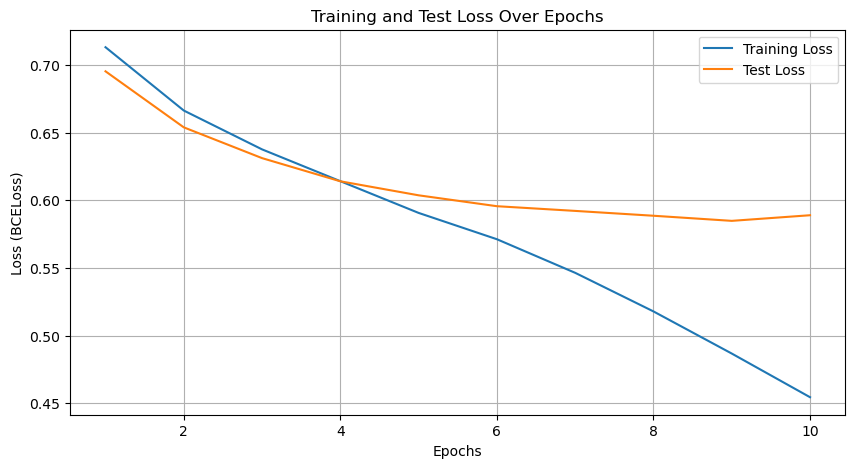

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Training Loss')
plt.plot(range(1, NUM_EPOCHS + 1), test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (BCELoss)')
plt.title('Training and Test Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

### 10.2. Plot Test Accuracy

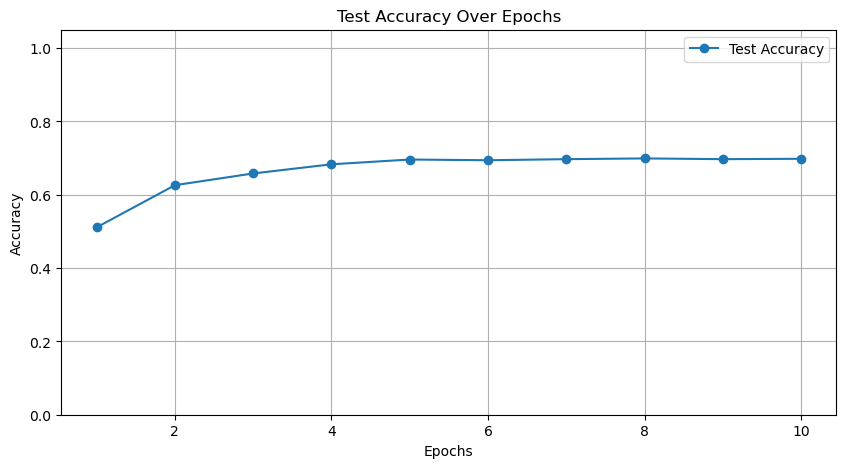


Final Test Accuracy: 0.6980
Final Test Loss: 0.5890


In [30]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), test_accuracies, label='Test Accuracy', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Test Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.ylim(0, 1.05) # Set y-axis limits for accuracy
plt.show()

print(f"\nFinal Test Accuracy: {test_accuracies[-1]:.4f}")
print(f"Final Test Loss: {test_losses[-1]:.4f}")
